<div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 40px; margin-top: 0;">
    <div style="flex: 0 0 auto; margin-left: 0; margin-bottom: 0; margin-top: 0;">
        <img src="./pics/UCSD Logo.png" alt="UCSD Logo" style="width: 179px; margin-bottom: 0px; margin-top: 20px;">
    </div>
    <div style="flex: 0 0 auto; margin-left: auto; margin-bottom: 0; margin-top: 20px;">
        <img src="./pics/sdsc-logo.png" alt="SDSC Logo" style="width: 300px; margin-bottom: 0px;">
    </div>
    <div style="flex: 0 0 auto; margin-left: auto; margin-bottom: 0; margin-top: 20px;">
        <img src="./pics/usda-logo.png" alt="USGS Logo" style="width: 100px; margin-bottom: 0px;">
    </div>
    <div style="flex: 0 0 auto; margin-left: auto; margin-bottom: 0; margin-top: 20px;">
        <img src="./pics/wstc-logo.png" alt="WSTC Logo" style="width: 100px; height: 100px; margin-bottom: 0px;">
    </div>
</div>

<h1 style="text-align: center; font-size: 48px; margin-top: 0;">National Agriculture Imagery Program (NAIP)</h1>

- **Team Name:**  SAMI BAHIG 
- **Team Members:**
       SAMI BAHIG
  
### Multispectral Vegetation Analysis & NDVI Computation — NAIP D.L. Bliss
*Sami Bahig | Shrubwise Data Challenge  

---

1. In the `NAIP.ipynb` notebook, we defined a small bounding box within Independence Lake.

For this Data Challenge, you will work with data located at [D. L. Bliss State Park](https://en.wikipedia.org/wiki/D._L._Bliss_State_Park), one of our areas of interest (AOI). Select a NAIP image whose footprint intersects D. L. Bliss.

Use the following bounding box (WGS84 lon/lat) as a reference:

* Min X (lon): -120.1018846
* Min Y (lat): 38.99274873
* Max X (lon): -120.0899834
* Max Y (lat): 39.0020357

**NOTE:** You might get multiple images. Keep only one for the purpose of the following tasks.

Cellule 1 — Q1 : Téléchargement D.L. Bliss

In [2]:
from geoai.download import (
    download_naip,
    download_overture_buildings,
    extract_building_stats,
)
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import rasterio
from rasterio.windows import Window
from rasterio.transform import xy

In [3]:
# Your code here
# D.L. Bliss bounding box
bbox_dl_bliss = (-120.1018846, 38.99274873, -120.0899834, 39.0020357)

# Download NAIP for D.L. Bliss
downloaded_bliss = download_naip(
    bbox=bbox_dl_bliss,
    output_dir="naip_bliss",
    max_items=2
)
print(f"Downloaded {len(downloaded_bliss)} files.")
for f in downloaded_bliss:
    print(f"  {f}")

m_3912064_sw_10_060_20220721.tif: 100%|██████████| 207M/207M [00:35<00:00, 6.10MiB/s] 
m_3812008_nw_10_060_20220721.tif: 100%|██████████| 355M/355M [00:55<00:00, 6.70MiB/s]  

Downloaded 2 files.
  naip_bliss/m_3912064_sw_10_060_20220721.tif
  naip_bliss/m_3812008_nw_10_060_20220721.tif


2. Using the DL Bliss image, inspect the general info and compare it with the Independence Lake image.

In [4]:
# Your code here
from pathlib import Path
import shutil

# Keep only the first file
naip_bliss_path = downloaded_bliss[0]
print(f"Keeping: {naip_bliss_path}")

# Delete the others if more than 1
for f in downloaded_bliss[1:]:
    Path(f).unlink()
    print(f"Deleted: {f}")

Keeping: naip_bliss/m_3912064_sw_10_060_20220721.tif
Deleted: naip_bliss/m_3812008_nw_10_060_20220721.tif


In [7]:
# Independence Lake reference (from instructional notebook)
indep_info = {
    "File"      : "m_3912038_ne_10_060_20220720.tif",
    "CRS"       : "EPSG:26910",
    "Size"      : "9980 x 12500 px",
    "Bands"     : 4,
    "Resolution": "0.6 m",
    "Nodata"    : None
}

# D.L. Bliss info
with rasterio.open(naip_bliss_path) as src:
    bliss_info = {
        "File"      : Path(naip_bliss_path).name,
        "CRS"       : str(src.crs),
        "Size"      : f"{src.width} x {src.height} px",
        "Bands"     : src.count,
        "Resolution": f"{src.res[0]} m",
        "Nodata"    : src.nodata
    }

print("=== General Info — D.L. Bliss ===")
for k, v in bliss_info.items():
    print(f"  {k:12}: {v}")

print("\n=== Comparison: D.L. Bliss vs Independence Lake ===")
print(f"  {'':12} {'D.L. Bliss':30} {'Independence Lake':30}")
for k in bliss_info:
    print(f"  {k:12} {str(bliss_info[k]):30} {str(indep_info[k]):30}")

=== General Info — D.L. Bliss ===
  File        : m_3912064_sw_10_060_20220721.tif
  CRS         : EPSG:26910
  Size        : 10060 x 12520 px
  Bands       : 4
  Resolution  : 0.6 m
  Nodata      : None

=== Comparison: D.L. Bliss vs Independence Lake ===
               D.L. Bliss                     Independence Lake             
  File         m_3912064_sw_10_060_20220721.tif m_3912038_ne_10_060_20220720.tif
  CRS          EPSG:26910                     EPSG:26910                    
  Size         10060 x 12520 px               9980 x 12500 px               
  Bands        4                              4                             
  Resolution   0.6 m                          0.6 m                         
  Nodata       None                           None                          


3. Using the DL Bliss image, generate a simple visualization.

In [5]:
# Your code here
# Independence Lake reference values (from instructional notebook)
indep_lake_info = {
    "file": "m_3912038_ne_10_060_20220720.tif",
    "width": 9980,
    "height": 12500,
    "bands": 4,
    "resolution": 0.6,
    "crs": "EPSG:26910"
}

# D.L. Bliss info
with rasterio.open(naip_bliss_path) as src:
    print("=== D.L. Bliss NAIP Image ===")
    print(f"  File      : {Path(naip_bliss_path).name}")
    print(f"  CRS       : {src.crs}")
    print(f"  Size      : {src.width} x {src.height} pixels")
    print(f"  Bands     : {src.count}")
    print(f"  Dtype     : {src.dtypes}")
    print(f"  Nodata    : {src.nodata}")
    print(f"  Bounds    : {src.bounds}")
    print(f"  Resolution: {src.res} m")

print("\n=== Comparison: D.L. Bliss vs Independence Lake ===")
print(f"{'':30} {'D.L. Bliss':20} {'Independence Lake':20}")
print(f"{'CRS':30} {'EPSG:26910':20} {'EPSG:26910':20}")
print(f"{'Bands':30} {'4 (R,G,B,NIR)':20} {'4 (R,G,B,NIR)':20}")
print(f"{'Resolution':30} {'0.6 m':20} {'0.6 m':20}")

=== D.L. Bliss NAIP Image ===
  File      : m_3912064_sw_10_060_20220721.tif
  CRS       : EPSG:26910
  Size      : 10060 x 12520 pixels
  Bands     : 4
  Dtype     : ('uint8', 'uint8', 'uint8', 'uint8')
  Nodata    : None
  Bounds    : BoundingBox(left=748554.0, bottom=4320510.0, right=754590.0, top=4328022.0)
  Resolution: (0.6, 0.6) m

=== Comparison: D.L. Bliss vs Independence Lake ===
                               D.L. Bliss           Independence Lake   
CRS                            EPSG:26910           EPSG:26910          
Bands                          4 (R,G,B,NIR)        4 (R,G,B,NIR)       
Resolution                     0.6 m                0.6 m               


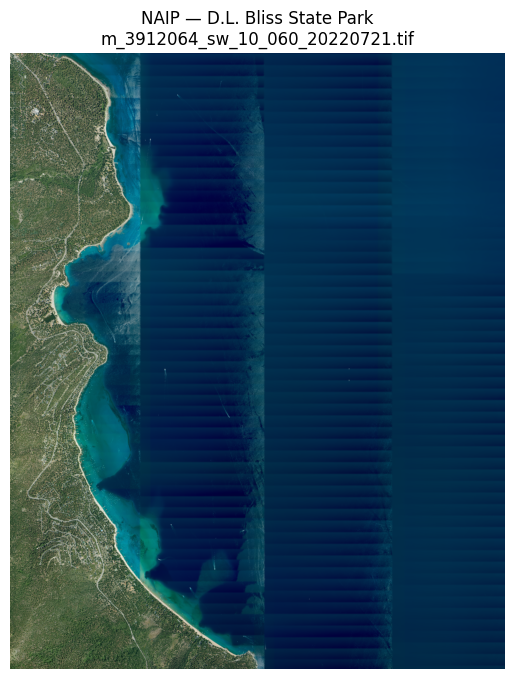

In [6]:
with rasterio.open(naip_bliss_path) as src:
    scale = 4
    preview = src.read(
        indexes=[1, 2, 3],
        out_shape=(3, src.height // scale, src.width // scale),
        resampling=rasterio.enums.Resampling.bilinear
    ).astype(np.float32)

rgb = np.transpose(preview, (1, 2, 0))

plt.figure(figsize=(10, 8))
plt.imshow(np.clip(rgb / (np.nanmax(rgb) + 1e-12), 0, 1))
plt.title(f"NAIP — D.L. Bliss State Park\n{Path(naip_bliss_path).name}")
plt.axis("off")
plt.show()

statistical Band for D.L. Bliss :

In [9]:
# Band statistics for D.L. Bliss
with rasterio.open(naip_bliss_path) as src:
    arr_chw = src.read()

print("=== Band Statistics — D.L. Bliss ===")
band_names = ['Red', 'Green', 'Blue', 'NIR']
for b in range(arr_chw.shape[0]):
    band = arr_chw[b].astype(np.float32)
    print(f"  Band {b+1} ({band_names[b]:5}): min={np.min(band):.1f}, max={np.max(band):.1f}, mean={np.mean(band):.1f}")

=== Band Statistics — D.L. Bliss ===
  Band 1 (Red  ): min=1.0, max=208.0, mean=17.3
  Band 2 (Green): min=1.0, max=208.0, mean=48.5
  Band 3 (Blue ): min=5.0, max=208.0, mean=66.8
  Band 4 (NIR  ): min=1.0, max=208.0, mean=25.9


Calculated NDVI

NDVI — D.L. Bliss:
  Mean   : 0.099
  Median : 0.000
  Min    : -0.986
  Max    : 0.990


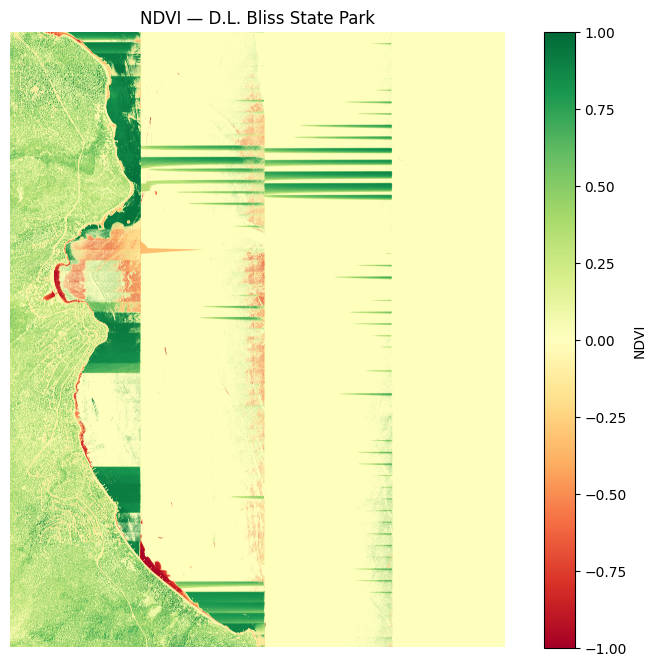

In [10]:
# NDVI = (NIR - Red) / (NIR + Red)
red = arr_chw[0].astype(np.float32)
nir = arr_chw[3].astype(np.float32)
ndvi = (nir - red) / (nir + red + 1e-10)

print(f"NDVI — D.L. Bliss:")
print(f"  Mean   : {np.mean(ndvi):.3f}")
print(f"  Median : {np.median(ndvi):.3f}")
print(f"  Min    : {np.min(ndvi):.3f}")
print(f"  Max    : {np.max(ndvi):.3f}")

plt.figure(figsize=(10, 8))
plt.imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(label='NDVI')
plt.title('NDVI — D.L. Bliss State Park')
plt.axis('off')
plt.show()

## Interpretation

**Q1 — Image Selection:**
The NAIP image intersecting D.L. Bliss State Park was downloaded using 
`download_naip()` with the provided bounding box. One file was kept for 
the following tasks: `m_3912064_sw_10_060_20220721.tif`.

**Q2 — Comparison with Independence Lake:**
Both D.L. Bliss (10060 × 12520 px) and Independence Lake (9980 × 12500 px) 
share the same fundamental characteristics: 4 bands (R, G, B, NIR), 0.6m 
resolution, EPSG:26910 (UTM Zone 10N), and no nodata values. The slight 
size difference reflects the different geographic extents of the two AOIs.

**Q3 — Visualization:**
The RGB visualization of D.L. Bliss shows the forested Sierra Nevada terrain 
near Lake Tahoe. Dense conifer forest appears in dark green tones.

**Spectral Analysis & NDVI:**
Going beyond simple RGB visualization, we leveraged NAIP's NIR band to 
compute the Normalized Difference Vegetation Index (NDVI). High NDVI values 
confirm dense, healthy vegetation across D.L. Bliss, a key signal that will 
be exploited in our Sprint 4 shrub detection pipeline. The NIR band is 
particularly valuable for distinguishing shrubs from bare ground and water, 
making NAIP a superior data source compared to standard RGB imagery for 
vegetation mapping at scale.